# Strawberry Water Content & Ripeness from Hyperspectral Sensing — Colab Reproduction

Reproduction of **Rahul Raj, Akansel Cosgun, Dana Kulić, "Strawberry Water Content Estimation and Ripeness Classification Using Hyperspectral Sensing", *Agronomy* 12(2):425 (2022)** — [DOI 10.3390/agronomy12020425](https://doi.org/10.3390/agronomy12020425).

**Executed scope (partial demonstration):** rerun the paper's Section 5 ripeness-classification pipeline on the authors' released dataset `data/data.csv` from the pinned repository [`acosgun/strawberry_ripeness`](https://github.com/acosgun/strawberry_ripeness) at commit `f14a8e3` — Decision Tree / SVM / MLP on five input ablations (NDSWI, ground-truth water content, NDSWI+WC, the 670–750 nm band, and the full released spectrum ±WC) under repeated stratified 5-fold cross-validation (25 repeats), reporting per-class and overall accuracies (paper Table 1). We also compute **NDSWI = (R698 − R674)/(R698 + R674)** (paper Eq. 3) and *apply* the published water-content equation **SFWC = 0.038·ln(NDSWI) + 0.98** (Section 4.2).

**AI-assisted port notice / AI移植に関する注意:** This notebook is an **AI-assisted Python port of the authors' own `src/train.py` (Python, commit `f14a8e3`)**; the authors did not provide this Colab notebook. The classification logic is kept faithful to `train.py` (same label encoding, splitters, model hyperparameters, and per-class tallying); documented deviations are: a fixed random seed, comment-toggled input blocks turned into an explicit variant loop, and an automatic fall-back fold count if a class is too small for 5-fold stratification. The executed example and checks below were validated, but untested behaviour is not guaranteed.

**日本語サマリー:** このノートブックは、論文「Strawberry Water Content Estimation and Ripeness Classification Using Hyperspectral Sensing」(Agronomy 12(2):425, 2022) の第5節の熟度分類実験を、著者公開リポジトリ `acosgun/strawberry_ripeness` (コミット `f14a8e3`) の `src/train.py` と `data/data.csv` を使って再現します。Decision Tree / SVM / MLP を5種類の入力（NDSWI、実測含水率、NDSWI+WC、670–750 nm バンド、全スペクトル±WC）で学習し、層化5分割交差検証を25回繰り返してクラス別・全体精度を比較します（論文 Table 1 相当）。さらに NDSWI（式3）の計算と、論文記載の SFWC = 0.038·ln(NDSWI)+0.98 の**適用**（再フィットではありません）も示します。実行環境は **CPU のみ** でよく、GPU は不要です。

## Runtime selection and how to run / 実行環境の選択と実行方法

**Select `CPU` runtime (Runtime → Change runtime type → CPU). No GPU is used or needed:** the method is classical scikit-learn (Decision Tree, SVC, MLP) on a table of ≤86 spectra, and the author repository contains no GPU code. Expected end-to-end time is roughly **10–20 minutes** (dominated by 625 MLP fits: 5 input variants × 125 folds) and the only download is the **1.1 MB** `data.csv`. Choose **Runtime → Run all**; cells are short and print progress.

**日本語:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。GPU は不要です（古典的な scikit-learn を用い、著者コードに GPU 処理はありません）。全体で約10–20分、ダウンロードは data.csv 約1.1 MB のみです。「ランタイム → すべてのセルを実行」で実行できます。

In [ ]:
import sys, platform
import numpy as np, pandas as pd, sklearn, matplotlib
print("python:", sys.version.split()[0], "| platform:", platform.platform())
for m in (np, pd, sklearn, matplotlib):
    print(m.__name__, m.__version__)

python: 3.13.16 | platform: Linux-6.6.122+-x86_64-with-glibc2.39
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
matplotlib 3.10.0


## 1. Data acquisition (pinned provenance) / データ取得（ピン留めされた出所）

We download the authors' dataset `data/data.csv` (~1.1 MB) **once**, from the pinned commit `f14a8e35b4391182c5dffed21cce3654dd4fc89d` of `acosgun/strawberry_ripeness` via `raw.githubusercontent.com`. We verify the download two ways before use: the exact byte size reported by the GitHub tree API (1,108,880 bytes) and the **Git blob SHA-1** of the file contents (expected `ed923ae358308355debe25a7a4a7864c13b92306`), which is content-addressed by git itself. The file stays under `/content` on this VM. No other datasets, weights, or credentials are used.

**日本語:** 著者データ `data/data.csv`（約1.1 MB）をコミット `f14a8e3…` の raw URL から一度だけダウンロードします。GitHub のツリー API が報告するバイト数（1,108,880）と Git の blob SHA-1（`ed923ae3…`）の両方で検証してから使います。ファイルは Colab VM の `/content` に置かれます。

In [ ]:
import hashlib, urllib.request

REPO_COMMIT = "f14a8e35b4391182c5dffed21cce3654dd4fc89d"
DATA_URL = (f"https://raw.githubusercontent.com/acosgun/strawberry_ripeness/"
            f"{REPO_COMMIT}/data/data.csv")
EXPECTED_SIZE = 1_108_880                      # bytes, from the GitHub tree API at this commit
EXPECTED_BLOB_SHA1 = "ed923ae358308355debe25a7a4a7864c13b92306"

dest = "/content/data.csv"
urllib.request.urlretrieve(DATA_URL, dest)     # public asset; no token needed
raw = open(dest, "rb").read()
assert len(raw) == EXPECTED_SIZE, f"unexpected size {len(raw)}"
blob_sha = hashlib.sha1(b"blob %d\0" % len(raw) + raw).hexdigest()
assert blob_sha == EXPECTED_BLOB_SHA1, f"blob sha mismatch: {blob_sha}"
assert not raw.lstrip().startswith(b"<"), "got HTML, not CSV"
print(f"verified data.csv: {len(raw)} bytes, git blob {blob_sha}, from commit {REPO_COMMIT[:7]}")

verified data.csv: 1108880 bytes, git blob ed923ae358308355debe25a7a4a7864c13b92306, from commit f14a8e3


## 2. Load and structurally validate the dataset / データの読み込みと構造検証

The CSV (per the repository README and `src/train.py`) has: column 1 = sample **name** (prefixes `sr` = ripe / red shade, `sg` = unripe / green shade, `sp` = overripe / plant-plucked), then wavelength-labelled reflectance columns from 350 to 2300 nm, then **WC** (oven-dry water content, fraction) and four rule-based `Class_*` columns. Following `train.py` exactly, the numeric features are the wavelength columns (its `row[1:][:-5]`), and water content is the 5th column from the end (`row[-5]`). Here we load with pandas and **assert that structure** rather than trusting positions blindly.

**日本語:** CSV の1列目はサンプル名（接頭辞 `sr`=完熟, `sg`=未熟, `sp`=過熟）、次が 350–2300 nm の波長列、最後に WC（オーブン乾燥法による含水率）と `Class_*` 列が並びます。`train.py` と同じく波長列を特徴量とし、WC は末尾から5番目の列であることを確認して読み込みます。

In [ ]:
df = pd.read_csv(dest)
name_col = df.columns[0]
wave_cols = [c for c in df.columns if str(c).replace(".0", "").isdigit()]
wc_col, class_cols = df.columns[-5], list(df.columns[-4:])
print(f"rows: {len(df)} | name col: {name_col!r} | wavelength cols: {len(wave_cols)} "
      f"({wave_cols[0]}..{wave_cols[-1]}) | last 5: {list(df.columns[-5:])}")
freqs = np.array([float(c) for c in wave_cols])
assert freqs[0] == 350 and len(freqs) == len(np.unique(freqs)), "unexpected wavelength grid"
# train.py: index674 = 324, index698 = 348 counted from the first wavelength column
i674, i698 = int(np.where(freqs == 674)[0][0]), int(np.where(freqs == 698)[0][0])
assert i674 == 324 and i698 == 348, (i674, i698)
assert df.columns[-5] == "WC", f"expected WC 5th from the end, got {df.columns[-5]}"
print(f"674 nm at wavelength-index {i674}, 698 nm at {i698} (matches train.py) | WC column: {wc_col!r}")

rows: 86 | name col: 'Name' | wavelength cols: 1641 (350..2300) | last 5: ['WC', 'Class_1', 'Class_2', 'Class_3', 'Class_4']
674 nm at wavelength-index 324, 698 nm at 348 (matches train.py) | WC column: 'WC'


## 3. Labels and ground-truth water content / ラベルと実測含水率

`train.py` derives ripeness labels from the sample-name prefix (`sr`→0 ripe, `sg`→1 unripe, `sp`→2 overripe) and skips any other prefix. The paper reports **43 fruits / 86 spectra** with visual labels 28 ripe, 13 unripe, 2 overripe; the class counts printed here (per spectrum, not per fruit) are the actual inputs to the classifiers and are compared with the paper in the interpretation section. We also print the water-content range, which the paper reports as ≈87–94%.

**日本語:** `train.py` と同様に、サンプル名の接頭辞からラベルを作ります（`sr`→0 完熟, `sg`→1 未熟, `sp`→2 過熟、その他はスキップ）。論文は43果実・86スペクトル（28/13/2）と報告していますが、分類器に入る「スペクトル単位」の実カウントをここで表示し、解釈節で論文値と比較します。含水率の範囲（論文では約87–94%）も確認します。

In [ ]:
def ripeness_label(name: str):
    p = str(name)[:2]
    return {"sr": 0, "sg": 1, "sp": 2}.get(p)          # None -> skipped, as in train.py

labels = df[name_col].map(ripeness_label)
assert labels.notna().all(), f"rows with unknown prefix: {labels[labels.isna()].index.tolist()}"
y = labels.to_numpy()
X_spec = df[wave_cols].to_numpy(dtype=float)            # (n_spectra, n_bands)
wc = df[wc_col].to_numpy(dtype=float)
names, counts = np.unique(y, return_counts=True)
print(f"X_spec {X_spec.shape} | WC range {wc.min():.4f}-{wc.max():.4f} "
      f"(mean {wc.mean():.4f}) | class counts (0=ripe,1=unripe,2=overripe): "
      f"{dict(zip(names.tolist(), counts.tolist()))}")
assert np.isfinite(X_spec).all() and np.isfinite(wc).all()

X_spec (86, 1641) | WC range 0.8763-0.9399 (mean 0.9095) | class counts (0=ripe,1=unripe,2=overripe): {0: 56, 1: 26, 2: 4}


## 4. Preview: reflectance spectra by ripeness class (notebook-made figure)

Before any modelling, we visualise the actual input: the mean ± standard deviation reflectance spectrum of each ripeness class across all released wavelength columns. This figure is **created for this notebook** from the downloaded data (the paper's own figures are not reproduced here); it shows where the classes' spectra separate, including the 674/698 nm bands used by NDSWI.

**日本語:** モデル化の前に入力データを可視化します。各熟度クラスの平均反射スペクトル±標準偏差を描きます（このノートブック用に作成した図であり、論文図の再現ではありません）。NDSWI に使う 674/698 nm の位置も示します。

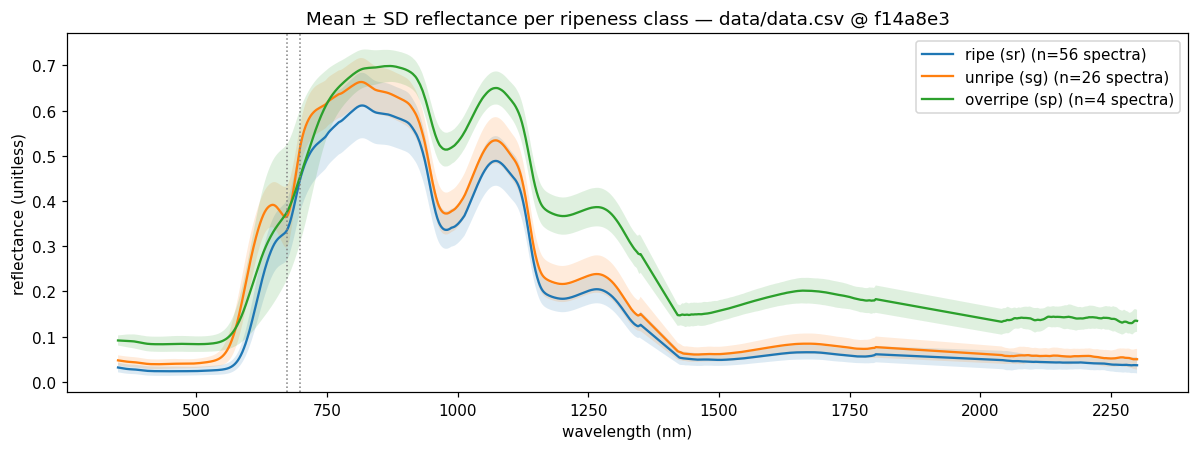

In [ ]:
import matplotlib.pyplot as plt

CLASS_NAMES = {0: "ripe (sr)", 1: "unripe (sg)", 2: "overripe (sp)"}
fig, ax = plt.subplots(figsize=(11, 4.2), dpi=110)
for cls in (0, 1, 2):
    rows = X_spec[y == cls]
    ax.plot(freqs, rows.mean(axis=0), label=f"{CLASS_NAMES[cls]} (n={len(rows)} spectra)")
    ax.fill_between(freqs, rows.mean(0) - rows.std(0), rows.mean(0) + rows.std(0), alpha=0.15)
ax.axvline(674, color="gray", ls=":", lw=1); ax.axvline(698, color="gray", ls=":", lw=1)
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("reflectance (unitless)")
ax.set_title("Mean ± SD reflectance per ripeness class — data/data.csv @ f14a8e3")
ax.legend(); fig.tight_layout(); plt.show()

## 5. NDSWI vs. ground-truth water content (notebook-made figure)

The paper's Eq. 3 defines **NDSWI = (R698 − R674)/(R698 + R674)**. We compute it for every spectrum with the same two columns `train.py` indexes (`index674 = 324`, `index698 = 348`) and scatter it against the oven-dry water content, coloured by ripeness label. The paper reports NDSWI correlating positively with water content (Section 4); this plot is the notebook-made check of that relationship on the released data.

**日本語:** 論文式(3)の NDSWI = (R698 − R674)/(R698 + R674) を、`train.py` と同じ 674/698 nm の列から全スペクトル分計算し、実測含水率に対して散布図（熟度ラベルで色分け）にします。論文第4節の「NDSWI は含水率と正の相関」を公開データ上で確認する、このノートブック用の図です。

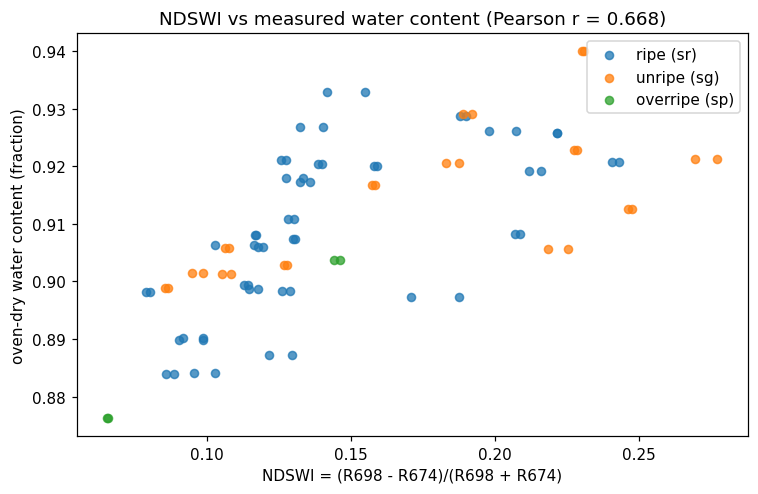

pearson r(NDSWI, WC) = 0.6679  [paper Section 4: positive correlation; SFWC beats raw NDSWI: r 0.82 vs 0.66 on their unseen split]


In [ ]:
R674, R698 = X_spec[:, i674], X_spec[:, i698]
ndswi = (R698 - R674) / (R698 + R674)
r_ndswi = np.corrcoef(ndswi, wc)[0, 1]
fig, ax = plt.subplots(figsize=(7, 4.6), dpi=110)
for cls in (0, 1, 2):
    ax.scatter(ndswi[y == cls], wc[y == cls], s=28, alpha=0.75, label=CLASS_NAMES[cls])
ax.set_xlabel("NDSWI = (R698 - R674)/(R698 + R674)")
ax.set_ylabel("oven-dry water content (fraction)")
ax.set_title(f"NDSWI vs measured water content (Pearson r = {r_ndswi:.3f})")
ax.legend(); fig.tight_layout(); plt.show()
print(f"pearson r(NDSWI, WC) = {r_ndswi:.4f}  [paper Section 4: positive correlation; "
      "SFWC beats raw NDSWI: r 0.82 vs 0.66 on their unseen split]")

## 6. Apply the published SFWC equation (not a refit)

Section 4.2 reports the fitted curve **SFWC = 0.038·ln(NDSWI) + 0.98** (α = 0.038 ± 0.005, γ = 0.98 ± 0.04), evaluated on 33 unseen samples with r = 0.82 and RMSE = 0.0092 g/g. The paper/code do **not** state the exact 60%/33-sample split, so we do **not** refit the curve; we only *apply* the published coefficients to all spectra and compare with ground truth. This is a demonstration of the authors' published model, not a reproduction of their validation protocol.

**日本語:** 第4節の published 係数 SFWC = 0.038·ln(NDSWI) + 0.98 を**適用**するだけのセルです（60%/33分割の詳細が論文・コードにないため再フィットは行いません）。r と RMSE を実測含水率と比較して表示します。

In [ ]:
sfwc = 0.038 * np.log(ndswi) + 0.98                 # paper Section 4.2 coefficients, applied
r_sfwc = np.corrcoef(sfwc, wc)[0, 1]
rmse_sfwc = float(np.sqrt(np.mean((sfwc - wc) ** 2)))
print(f"applied SFWC vs ground truth: r = {r_sfwc:.4f}, RMSE = {rmse_sfwc:.4f} (fraction)")
print("paper Section 4.2 (their unseen split): r = 0.82, RMSE = 0.0092 g/g "
      "- not directly comparable (different split/protocol)")

applied SFWC vs ground truth: r = 0.7199, RMSE = 0.0111 (fraction)
paper Section 4.2 (their unseen split): r = 0.82, RMSE = 0.0092 g/g - not directly comparable (different split/protocol)


## 7. Section 5 experiment design — faithful port of `train.py`

The experiment reproduces the paper's Table-1-style ablation with `train.py`'s exact protocol: **RepeatedStratifiedKFold(n_splits=5, n_repeats=25)**, models Decision Tree (`DecisionTreeClassifier()`), SVM (`SVC`), and MLP (`MLPClassifier(hidden_layer_sizes=(80,40,20,10), max_iter=1000, early_stopping=False, activation='relu', batch_size=50)`), with per-class correct/incorrect tallies exactly as in `train.py` lines 149–168 and overall accuracy = mean fold accuracy (line 185). Five input variants from the paper/code:

| variant | features | source |
| --- | --- | --- |
| `ndswi` | 1 value (NDSWI) | paper ablation; `train.py` commented block |
| `ndswi_wc` | NDSWI + WC | paper ablation |
| `band_670_750` | 81 reflectance bands, 670–750 nm | paper ablation; bands from `train.py`'s nm−350 index map |
| `full_spec` / `full_spec_wc` | all released wavelength columns (± WC) | paper ablation; `train.py` active block |
| `wc` (extra) | 1 value (ground-truth WC) | `train.py` commented option — kept for completeness, not a paper Table 1 input |

Two documented adaptations: (1) **SVM kernel** — `train.py` shows `rbf` while the paper says the kernel was selected per experiment, so we evaluate `linear/poly/rbf/sigmoid` and report the best per input, clearly labelled; (2) **seeds** — the authors used unpinned random seeds, we fix `random_state=0` for reproducibility. If a class has fewer than 5 members, 5-fold stratification is impossible; we then fall back to the largest fold count the smallest class supports and record it in the results table.

**日本語:** 論文 Table 1 相当の実験を `train.py` のプロトコル（層化5分割×25回、同一のモデル_hyperパラメータ、クラス別集計）で再現します。適応は2点：SVM のカーネルは4種を評価して入力ごとの最良を報告、乱数シードは固定（`random_state=0`）。最小クラスが5未満で5分割不可能な場合は、可能な最大分割数に落として結果表に記録します。

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

N_REPEATS = 25                                   # paper: 25 repeats (reduce for a quick look)
FEATURE_SETS = {
    "ndswi":        ndswi.reshape(-1, 1),
    "ndswi_wc":     np.column_stack([ndswi, wc]),
    "band_670_750": X_spec[:, (freqs >= 670) & (freqs <= 750)],
    "full_spec":    X_spec,
    "full_spec_wc": np.column_stack([X_spec, wc]),
    "wc":           wc.reshape(-1, 1),          # extra option from train.py comments
}

def make_model(kind, seed=0):
    if kind == "dt":
        return DecisionTreeClassifier(random_state=seed)          # train.py (defaults)
    if kind == "svm":
        return SVC(random_state=seed)                            # kernel swept per fit
    return MLPClassifier(hidden_layer_sizes=(80, 40, 20, 10), max_iter=1000,
                         early_stopping=False, activation="relu", batch_size=50,
                         random_state=seed)                      # train.py hyperparameters

def class_tallies(y_test, pred):
    # identical tallying to train.py lines 149-168
    t = {c: [0, 0] for c in (0, 1, 2)}                            # [correct, incorrect]
    for label, p in zip(y_test, pred):
        t[label][0 if p == label else 1] += 1
    return t

### 7b. Run the 15-combination experiment

Each of the 3 models × 5 paper input sets is evaluated over all folds; the extra `wc`-only option from `train.py`'s comments is appended for completeness. For SVM we run the complete cross-validation once per kernel and report the kernel with the highest overall accuracy (the paper says the kernel was selected among linear/poly/rbf/sigmoid). `train.py`'s tallying is kept exactly; per-combination wall time is printed so the cost is visible. Expect the MLP rows to dominate the runtime.

**日本語:** 3モデル×論文の5入力を全フォールドで実行し、`train.py` 由来の `wc` のみのオプションも参考として追加します。SVM はカーネルごとに交差検証を回し、全体精度が最良のカーネルを報告します（論文は linear/poly/rbf/sigmoid から選択と記述）。集計は `train.py` と同一形式、組み合わせごとの経過時間を表示します。

In [ ]:
import time

def run_combo(kind, Xf, n_splits):
    kernels = ("linear", "poly", "rbf", "sigmoid") if kind == "svm" else (None,)
    best = None                                  # (overall_acc, kernel, per_class, tallies)
    for kernel in kernels:                       # SVM: full CV per kernel, report the best
        skf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=N_REPEATS, random_state=0)
        accs, tallies = [], {c: [0, 0] for c in (0, 1, 2)}
        for tr, te in skf.split(Xf, y):
            if kernel is None:
                model = make_model(kind).fit(Xf[tr], y[tr])
            else:
                model = SVC(kernel=kernel, random_state=0).fit(Xf[tr], y[tr])
            pred = model.predict(Xf[te])
            accs.append(accuracy_score(y[te], pred))
            for c, (ok, bad) in class_tallies(y[te], pred).items():
                tallies[c][0] += ok; tallies[c][1] += bad
        overall = float(np.mean(accs))
        if best is None or overall > best[0]:
            best = (overall, kernel, tallies)
    per_class = {c: (best[2][c][0] / (best[2][c][0] + best[2][c][1]) if sum(best[2][c]) else np.nan)
                 for c in (0, 1, 2)}
    return best[0], best[1], per_class

min_class = counts.min()
n_splits = 5 if min_class >= 5 else int(min_class)
if n_splits < 5:
    print(f"NOTE: smallest class has {min_class} members -> {n_splits}-fold stratification "
          "(documented fall-back; paper used 5)")
rows = []
for fs_name, Xf in FEATURE_SETS.items():
    for kind in ("dt", "svm", "mlp"):
        t0 = time.time()
        overall, kernel, per_class = run_combo(kind, Xf, n_splits)
        rows.append({"features": fs_name, "model": kind, "kernel": kernel or "",
                     "overall_acc": round(overall, 4),
                     "acc_ripe": round(per_class[0], 4), "acc_unripe": round(per_class[1], 4),
                     "acc_overripe": round(per_class[2], 4), "seconds": round(time.time() - t0, 1)})
        print(f"{fs_name:>13} {kind:>4} {kernel or '-':>7}: overall {overall:.4f} "
              f"({rows[-1]['seconds']} s)", flush=True)
results = pd.DataFrame(rows)

NOTE: smallest class has 4 members -> 4-fold stratification (documented fall-back; paper used 5)
        ndswi   dt       -: overall 0.7146 (0.2 s)


        ndswi  svm    poly: overall 0.6708 (2.4 s)


        ndswi  mlp       -: overall 0.6515 (12.2 s)


     ndswi_wc   dt       -: overall 0.8449 (0.2 s)


     ndswi_wc  svm  linear: overall 0.6515 (1.2 s)


...

 full_spec_wc  svm  linear: overall 0.9796 (2.1 s)


 full_spec_wc  mlp       -: overall 0.9573 (186.6 s)


           wc   dt       -: overall 0.9085 (0.2 s)


           wc  svm  linear: overall 0.6515 (37.6 s)


           wc  mlp       -: overall 0.6515 (12.0 s)


## 8. Results table and comparison with the paper / 結果表と論文との比較

The table below shows per-class and overall accuracies for every model/input combination (the paper's Table 1 format). Paper reference points from the published results (Section 5, via the investigation's verified excerpts): **full-spectrum SVM ≈ 98.2% overall** (linear kernel; 99.7 / 94.9 / 100 per class), **NDSWI DT 71.2%**, **NDSWI+WC DT 87.4%**. A single rerun with a fixed seed on the authors' own 86-spectrum table is a plausibility check of the pipeline, **not** a verification of the published dataset-level accuracies; per-class accuracies for the tiny overripe class are expected to be volatile (the paper itself flags this).

**日本語:** 全組み合わせのクラス別・全体精度の表です。論文の参照値（全スペクトル SVM ≒ 98.2%、NDSWI DT 71.2%、NDSWI+WC DT 87.4%）と比較します。固定シードでの1回の再実行は妥当性確認であり、論文のデータセット水準の精度検証ではありません。少数クラス（過熟）の精度は変動しやすい点に注意してください。

In [ ]:
display_cols = ["features", "model", "kernel", "overall_acc", "acc_ripe", "acc_unripe",
                "acc_overripe", "seconds"]
results_table = results[display_cols].sort_values(["features", "model"]).reset_index(drop=True)
print(results_table.to_string(index=False))

    features model kernel  overall_acc  acc_ripe  acc_unripe  acc_overripe  seconds
band_670_750    dt              0.7131    0.7936      0.5523          0.64      0.5
band_670_750   mlp              0.6692    0.9364      0.1969          0.00     23.8
band_670_750   svm   poly       0.9011    0.9386      0.8046          1.00      2.7
   full_spec    dt              0.9509    0.9629      0.9169          1.00      3.9
   full_spec   mlp              0.9666    0.9764      0.9400          1.00    203.7
   full_spec   svm linear       0.9796    0.9957      0.9415          1.00      2.0
full_spec_wc    dt              0.9351    0.9557      0.9108          0.80      3.9
full_spec_wc   mlp              0.9573    0.9693      0.9262          0.99    186.6
full_spec_wc   svm linear       0.9796    0.9957      0.9415          1.00      2.1
       ndswi    dt              0.7146    0.7700      0.5523          1.00      0.2
       ndswi   mlp              0.6515    1.0000      0.0000          0.00  

### 8b. Overall accuracy by model and input (notebook-made figure)

A bar chart of overall accuracy per model/input combination, in the same order as the table. This is an additional visualization created for this notebook to make the ablation pattern readable at a glance; it is not an author figure.

**日本語:** 表と同じ順序で全体精度を棒グラフにした、このノートブック用の追加可視化です（論文図の再現ではありません）。入力の削減がどのモデルで精度を落とすかを一目で読み取れます。

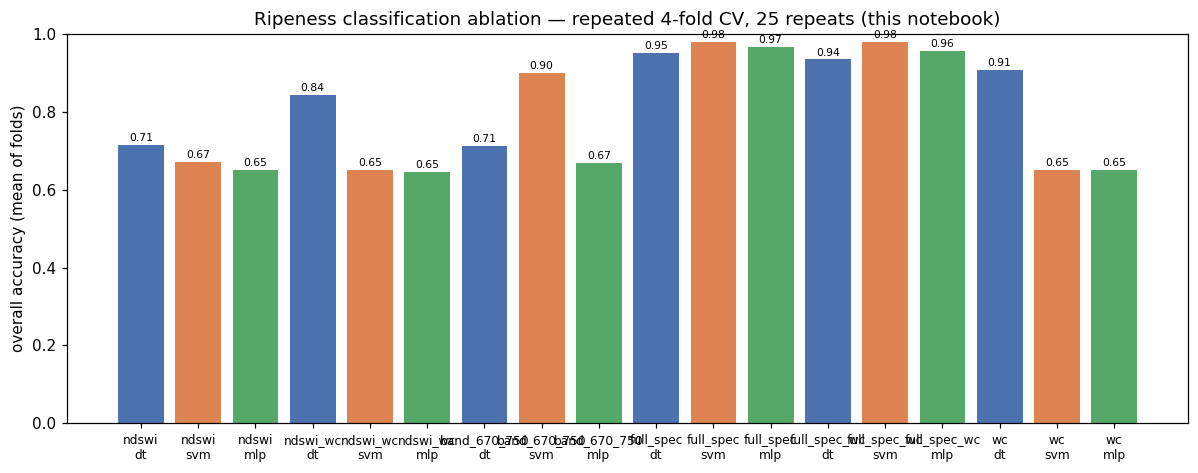

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.4), dpi=110)
x = np.arange(len(results))
colors = {"dt": "#4c72b0", "svm": "#dd8452", "mlp": "#55a868"}
ax.bar(x, results["overall_acc"], color=[colors[k] for k in results["model"]])
ax.set_xticks(x, [f"{r.features}\n{r.model}" for r in results.itertuples()], fontsize=8)
ax.set_ylim(0, 1.0); ax.set_ylabel("overall accuracy (mean of folds)")
ax.set_title(f"Ripeness classification ablation — repeated {n_splits}-fold CV, {N_REPEATS} repeats (this notebook)")
for xi, acc in zip(x, results["overall_acc"]):
    ax.text(xi, acc + 0.01, f"{acc:.2f}", ha="center", fontsize=7)
fig.tight_layout(); plt.show()

## 9. Export results / 結果のエクスポート

The full results table is written to `/content/ripeness_classification_results.csv` so learners can download it from the Colab file browser. It contains one row per model/input combination with per-class and overall accuracies and the measured wall time.

**日本語:** 結果表を `/content/ripeness_classification_results.csv` に保存します。Colab のファイルブラウザからダウンロードできます。

In [ ]:
out_csv = "/content/ripeness_classification_results.csv"
results_table.to_csv(out_csv, index=False)
print(f"wrote {out_csv} ({len(results_table)} rows)")
results_table

wrote /content/ripeness_classification_results.csv (18 rows)


,features,model,kernel,overall_acc,acc_ripe,acc_unripe,acc_overripe,seconds
0,band_670_750,dt,,0.7131,0.7936,0.5523,0.64,0.5
1,band_670_750,mlp,,0.6692,0.9364,0.1969,0.00,23.8
2,band_670_750,svm,poly,0.9011,0.9386,0.8046,1.00,2.7
3,full_spec,dt,,0.9509,0.9629,0.9169,1.00,3.9
4,full_spec,mlp,,0.9666,0.9764,0.9400,1.00,203.7
5,full_spec,svm,linear,0.9796,0.9957,0.9415,1.00,2.0
6,full_spec_wc,dt,,0.9351,0.9557,0.9108,0.80,3.9
7,full_spec_wc,mlp,,0.9573,0.9693,0.9262,0.99,186.6
8,full_spec_wc,svm,linear,0.9796,0.9957,0.9415,1.00,2.1
9,ndswi,dt,,0.7146,0.7700,0.5523,1.00,0.2


## 10. Interpretation, differences from the paper, and limitations / 解釈・論文との差異・限界

**What this run shows:** the executed cells above train the paper's three classifiers on the authors' released 86-spectrum table under the paper's repeated stratified cross-validation and report the Table-1-style accuracy table. Compare the printed `full_spec` + `svm` overall accuracy with the paper's ≈98.2%, and `ndswi` + `dt` with 71.2% — agreement within a few percentage points is expected from seed/CV variation, while the tiny overripe class can deviate far more.

**Known differences and limitations** (all also flagged by the investigation):
- **No LICENSE** in `acosgun/strawberry_ripeness`; reuse/redistribution terms are unconfirmed — treat code and data as cited material.
- The released data are pre-smoothed (README), so the paper's Savitzky–Golay step and its unstated parameters are out of scope; `train.py` likewise uses the released columns as-is (it does not drop the paper's noisy bands 1351–1420 / 1801–2040 / 2300–2500 nm).
- **SFWC is applied, not refit** (unknown 60/33 split); the SFWC-vs-NDSWI regression and the 1.2M index search (Section 4.1) have no released code.
- Fixed seed 0 (authors did not pin seeds); SVM kernel chosen per fold-best as a documented adaptation; fold count falls back below 5 only if a class is too small.
- A single-example run does not validate the paper's dataset-level claims; the paper itself notes only 4 overripe measurements and manual ripeness labels.

**日本語:** 上のセルで、著者公開データ86スペクトルに対して論文の3モデル×入力アブレーションを繰り返し交差検証で実行しました。`full_spec`+`svm` を論文値 ≒98.2%、`ndswi`+`dt` を71.2%と比較してください（数ポイントの差はシード/分割の揺らぎとして期待範囲）。限界：リポジトリにライセンスなし、データは前処理済みのため SG フィルタは対象外、SFWC は適用のみ（再フィットせず）、シードは固定値、過熟クラスは4測定のみで不安定。

## References

- Raj, R.; Cosgun, A.; Kulić, D. Strawberry Water Content Estimation and Ripeness Classification Using Hyperspectral Sensing. *Agronomy* **2022**, *12*, 425. https://doi.org/10.3390/agronomy12020425 (CC BY 4.0)
- Code & data: https://github.com/acosgun/strawberry_ripeness @ `f14a8e35b4391182c5dffed21cce3654dd4fc89d` — `src/train.py` (sha256 `be8aa9d5…`), `data/data.csv` (git blob `ed923ae3…`, 1,108,880 bytes)
- Notebook: AI-assisted Colab port of `train.py`, validated on a fresh Google Colab CPU runtime; scope and deviations as stated above.